In [1]:
import sys, os
sys.path.append(os.getcwd().split('src')[0] + 'src')
from utils import *
manifold_type = 'S2'
manifold = get_manifold(manifold_type)

In [2]:
n_samples = 5000
sigma2 = .1

# prior param
num_modes = 3
tau2 = 0.05
G = G = lambda n: multimodal_sampler(manifold_type, n, tau2, num_modes) 

# get data
Theta = multimodal_sampler(manifold_type, n_samples, tau2, num_modes)
X = manifold.random_riemannian_normal(Theta, 1./(sigma2), n_samples)

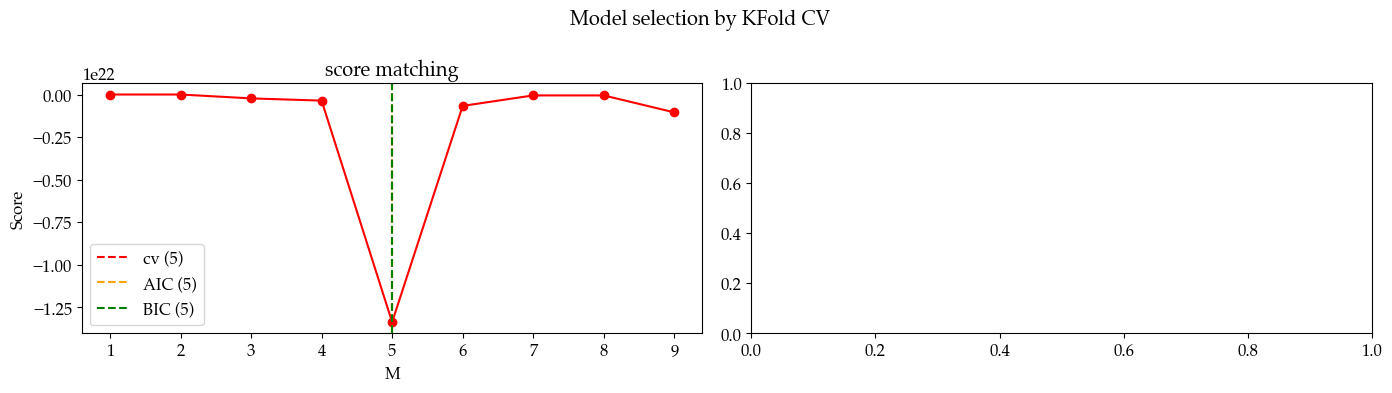

<Figure size 640x480 with 0 Axes>

In [14]:
if True:
    M_grid = np.arange(1, 10)

    selectors = [
        dict(
            title="score matching",
            func=select_M_by_scoreMatchingKFoldCV,
            kwargs=dict(
                n_splits=50,
                return_scores=True,
                random_state=None,
                rho=1e-12,
                tryearlystop=False,
            ),
            line_color="red",
        ),
        dict(
            title="density matching",
            func=select_M_by_DensityKFoldCV,
            kwargs=dict(
                n_splits=50,
                return_scores=True,
            ),
            line_color="red",
        ),
    ]

    results = []
    for s in selectors:
        Mstar, vals = s["func"](manifold_type, X, M_grid, **s["kwargs"])
        results.append((s["title"], Mstar, vals, s["line_color"]))

    fig, axs = plt.subplots(1, len(results), figsize=(14, 4), sharex=False, sharey=False)
    fig.suptitle("Model selection by KFold CV")

    if len(results) == 1:
        axs = [axs]

    vlines = [("cv", "red"), ("AIC", "orange"), ("BIC", "green")]

    for ax, (title, Mstar, vals, line_color) in zip(axs, results):
        M_grid_ = M_grid[: len(vals)]
        ax.plot(M_grid_, vals, marker="o", color=line_color)

        for key, c in vlines:
            ax.axvline(Mstar[key], color=c, linestyle="--", label=f"{key} ({Mstar[key]})")

        ax.set_title(title)
        ax.set_xlabel("M")
        ax.set_xticks(M_grid)
        ax.set_ylabel("Score")
        ax.legend()

        plt.tight_layout()
        plt.show()

In [15]:
# for empirical density estimation
M = 5
rho = 0.001
# for oracle approximation
num_oracle_samples = 10000
oracle_bandwidth = 0.001



In [16]:
# --- denoisers
delta = denoiser(manifold_type, X, M, rho, sigma2, X)
oracle_delta_T = oracle_denoiser(manifold_type, num_oracle_samples, sigma2, X, G )
oracle_delta_B = oracle_bayes__kernel(manifold_type, num_oracle_samples, sigma2, oracle_bandwidth, X, G )
# --- losses
loss_N = sq_loss(manifold, X, Theta)
loss_T = sq_loss(manifold, delta, Theta) 
loss_oracle_T = sq_loss(manifold, oracle_delta_T, Theta) 
loss_oracle_B = sq_loss(manifold, oracle_delta_B, Theta) 

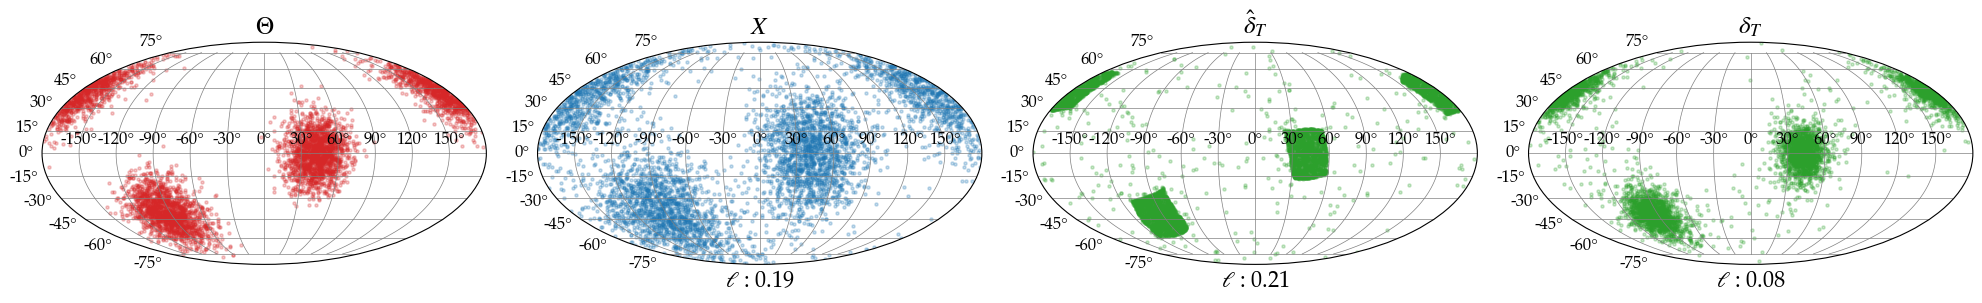

In [17]:
if True:
    fig, axs = plt.subplots(1, 4, figsize=(20, 5), subplot_kw={'projection': 'mollweide'})

    S2scatter(Theta, axs[0], color='C3', alpha=0.25)
    axs[0].set_title(r'$\Theta$', fontsize=18)

    S2scatter(X, axs[1], color='C0', alpha=0.25)
    axs[1].set_title(r'$X$', fontsize=18)
    axs[1].set_xlabel(rf'$\ell$ : {loss_N:.2f}', fontsize=16)

    S2scatter(delta, axs[2], color='C2', alpha=0.25)
    axs[2].set_title(r'$\hat\delta_T$', fontsize=18)
    axs[2].set_xlabel(rf'$\ell$ : {loss_T:.2f}', fontsize=16)

    S2scatter(oracle_delta_T, axs[3], color='C2', alpha=0.25)
    axs[3].set_title(r'$\delta_T$', fontsize=18)
    axs[3].set_xlabel(rf'$\ell$ : {loss_oracle_T:.2f}', fontsize=16)

    plt.savefig('denoising_S2.png', bbox_inches='tight')
    plt.tight_layout()
    plt.show()

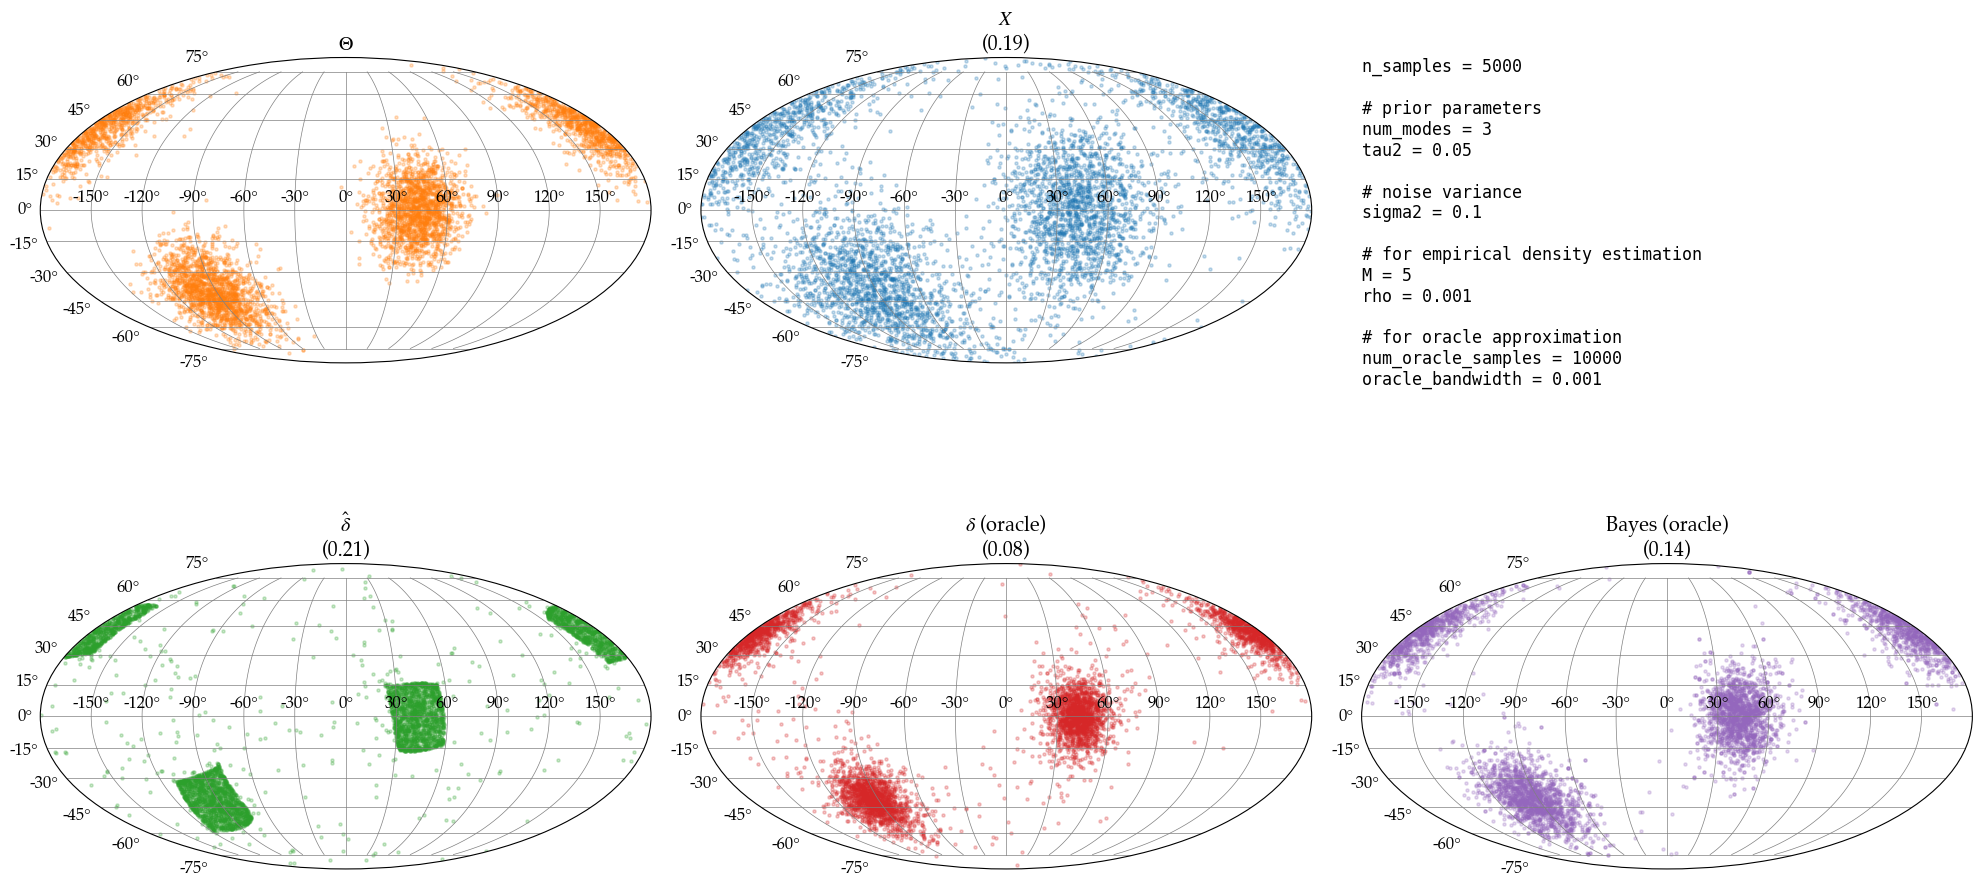

In [18]:
if True:
    # Single figure: 2 on top, 3 on bottom
    fig, axs = plt.subplots(2, 3, figsize=(20, 10), subplot_kw={'projection': 'mollweide'})

    # --- top row (use first two axes, use the third for a text panel) ---
    S2scatter(Theta, axs[0, 0], color='C1', alpha=0.25)
    axs[0, 0].set_title(r'$\Theta$')

    S2scatter(X, axs[0, 1], color='C0', alpha=0.25)
    axs[0, 1].set_title(rf'$X$' + '\n' + f'({loss_N:.2f})')

    # --- top-right: info panel ---
    axs[0, 2].set_axis_off()
    info = (
        f"n_samples = {n_samples}\n\n"
        f"# prior parameters\n"
        f"num_modes = {num_modes}\n"
        f"tau2 = {tau2}\n\n"
        f"# noise variance\n"
        f"sigma2 = {sigma2}\n\n"
        f"# for empirical density estimation\n"
        f"M = {M}\n"
        f"rho = {rho}\n\n"
        f"# for oracle approximation\n"
        f"num_oracle_samples = {num_oracle_samples}\n"
        f"oracle_bandwidth = {oracle_bandwidth}"
    )
    axs[0, 2].text(
        0.0, 1.0, info,
        transform=axs[0, 2].transAxes,
        va="top", ha="left",
        fontsize=12, family="monospace"
    )

    # --- bottom row (three denoisers) ---
    S2scatter(delta, axs[1, 0], color='C2', alpha=0.25)
    axs[1, 0].set_title(rf'$\hat\delta$' + '\n' + f'({loss_T:.2f})')
    S2scatter(oracle_delta_T, axs[1, 1], color='C3', alpha=0.25)
    axs[1, 1].set_title(rf'$\delta$ (oracle)' + '\n' + f'({loss_oracle_T:.2f})')

    S2scatter(oracle_delta_B, axs[1, 2], color='C4', alpha=0.25)
    axs[1, 2].set_title(rf'Bayes (oracle)' + '\n' + f'({loss_oracle_B:.2f})')

    plt.savefig('denoising_S2.png', bbox_inches='tight')
    plt.tight_layout()
    plt.show()

In [19]:
grid_resolution = 50
grid, grid_theta, grid_phi = S2grid(grid_resolution)
_, hat_f, grad_hat_f, = density_estimate('S2', X, M, grid)
# _, hat_f, grad_hat_f, = kernel_density_estimate('S2', X, M, grid)


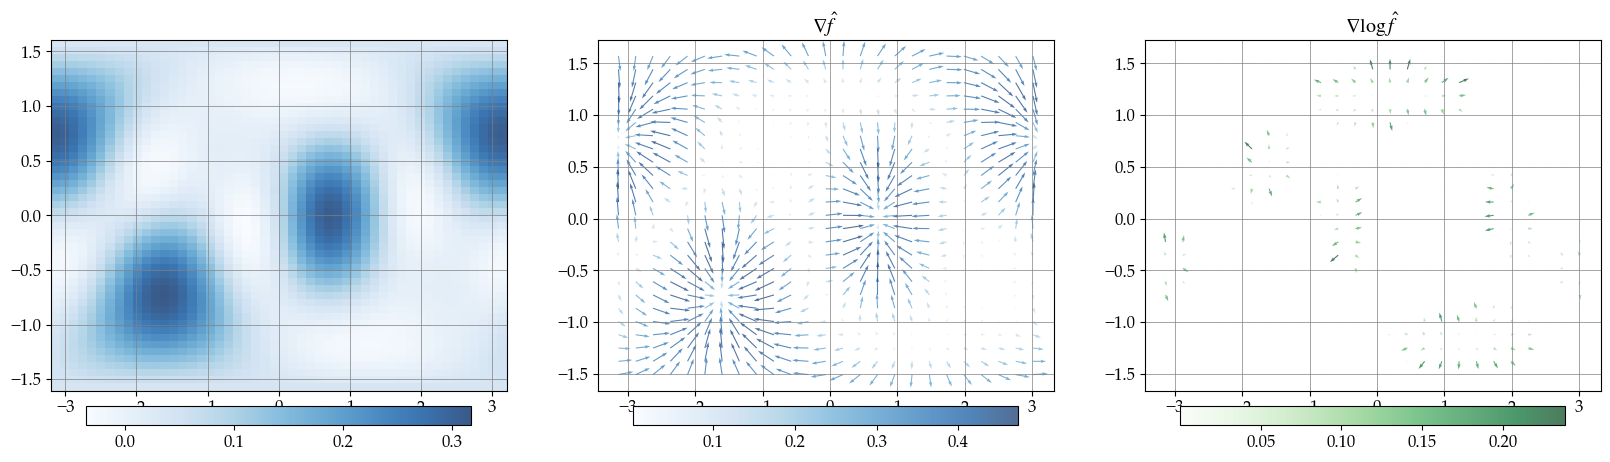

In [20]:
fig, axs = plt.subplots(1, 3, figsize=(20, 5), 
                        # subplot_kw={'projection': 'mollweide'}
                        )
skip = 2
S2plot_quiver(fig, {'f' : hat_f, 'grad_f' : grad_hat_f}, rho, 'gradient', axs[1], skip = skip, grid_resolution = grid_resolution, scale =10)
S2plot_quiver(fig, {'f' : hat_f, 'grad_f' : grad_hat_f}, rho, 'score', axs[2], skip = skip, grid_resolution = grid_resolution, scale =10)
im = axs[0].pcolormesh( grid_phi - np.pi, np.pi/2 - grid_theta, hat_f.reshape(grid_resolution,grid_resolution), alpha=0.8, shading='auto', cmap='Blues')
fig.colorbar(im, ax= axs[0], orientation='horizontal', fraction=0.05, pad=0.04)
axs[0].grid(True, color='gray', lw=0.5)


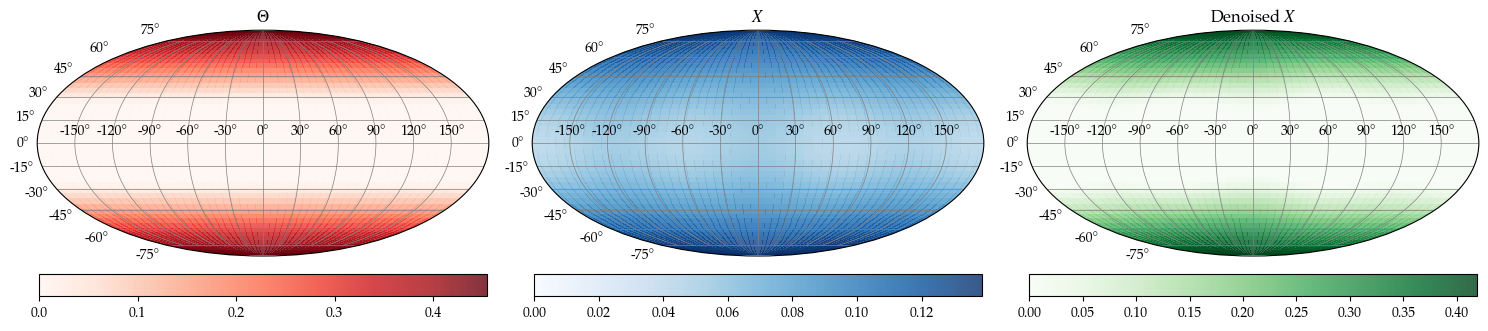

In [ ]:
# fig, axs = plt.subplots(1, 3, figsize=(15, 5), subplot_kw={'projection': 'mollweide'})

# grid_resolution = 50
# grid, grid_theta, grid_phi = S2grid(grid_resolution)

# densities = [density_estimate('S2', data, M, grid)[1].reshape(grid_resolution, grid_resolution) for data in [Theta, X, delta]]
# vmax = None #max([d.max() for d in densities])

# for hat_f, ax, title, cmap in zip(densities, axs, ['$\\Theta$', '$X$', 'Denoised $X$'], ['Reds', 'Blues', 'Greens']):
#     im = ax.pcolormesh( grid_phi - np.pi, np.pi/2 - grid_theta, hat_f,
#                     alpha=0.8, shading='auto', cmap=cmap, vmin=0, vmax=vmax)
#     fig.colorbar(im, ax=ax, orientation='horizontal', fraction=0.05, pad=0.04)
#     ax.grid(True, color='gray', lw=0.5)
#     ax.set_title(title)
# plt.tight_layout(); plt.show()

# # fig = S2plot_density_gradient_score(X,M,sigma2,rho, grid_resolution =50, skip=2, mollwide=True); plt.show()

   